#  MENTHEALTH: PREDICTING THE HEALTH OF THE MOST IMPORTANT ORGAN OF THE BODY
**Project Goal:** Use lifestyle data to predict whether a person is at risk of stress/depression

### How it works (Simple Flow):
```
Lifestyle Data (sleep, work, exercise...) → ML Model → Predict Mental Health Risk
```

### Dataset:
We use the **Student Mental Health dataset** from Kaggle.
Download link: https://www.kaggle.com/datasets/shariful07/student-mental-health
- Download the CSV file and place it in the same folder as this notebook
- Rename it to `mental_health.csv`

### Libraries we use:
- `pandas` → handle data
- `matplotlib` & `seaborn` → charts
- `sklearn` → build and evaluate the ML model

## Step 1: Install Required Libraries

In [1]:
!pip install pandas matplotlib seaborn scikit-learn

## Step 2: Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported!')

All libraries imported!


## Step 3: Load the Dataset

In [3]:
df = pd.read_csv('mental_health.csv')

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print()
print('Column names:')
print(df.columns.tolist())
df.head()

Dataset loaded: 101 rows, 11 columns

Column names:
['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## Step 4: Explore the Data
Before building a model, we always explore the data first to understand it.

In [4]:

print(' Dataset Info:')
print(df.info())
print()
print('Missing values per column:')
print(df.isnull().sum())

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 

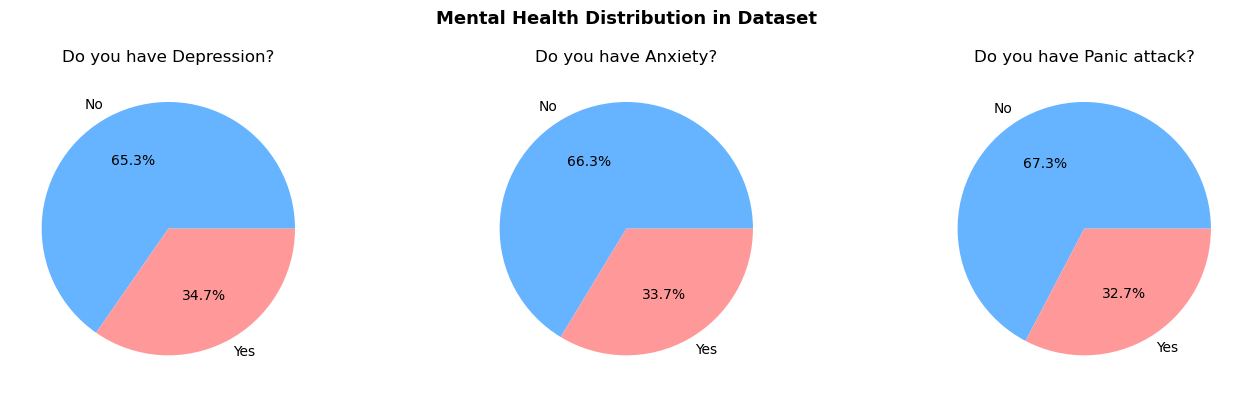

In [5]:
# How many students have depression, anxiety, panic attacks?
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?']):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
    ax.set_title(col)

plt.suptitle('Mental Health Distribution in Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

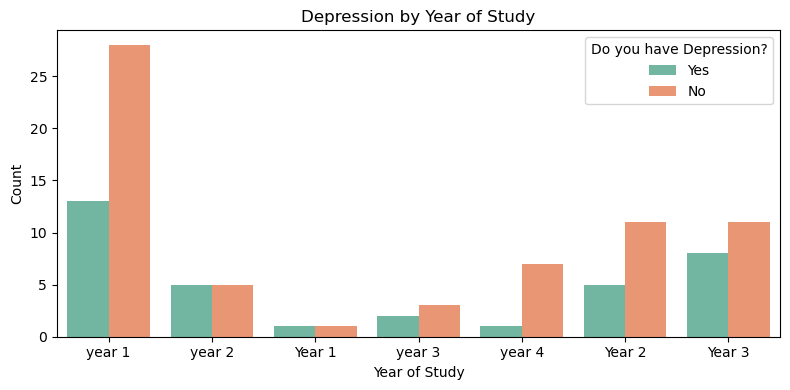

In [6]:
# Depression by Year of Study
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Your current year of Study', hue='Do you have Depression?', palette='Set2')
plt.title('Depression by Year of Study')
plt.xlabel('Year of Study')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

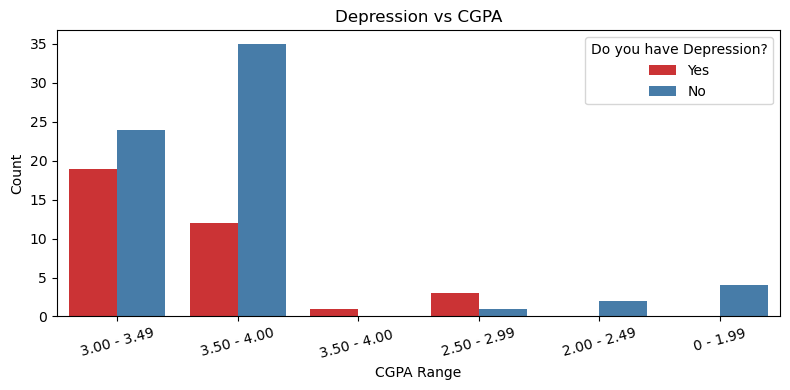

In [7]:
# Depression by GPA
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='What is your CGPA?', hue='Do you have Depression?', palette='Set1')
plt.title('Depression vs CGPA')
plt.xlabel('CGPA Range')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Step 5: Data Cleaning & Preprocessing
ML models only understand numbers, so we convert text columns to numbers.

In [8]:

clean_df = df.copy()

clean_df.columns = [
    'timestamp', 'gender', 'age', 'course', 'year',
    'cgpa', 'married', 'depression', 'anxiety', 'panic_attack', 'treatment'
]

clean_df = clean_df.drop(columns=['timestamp'])

clean_df = clean_df.dropna()

print(f'Clean dataset: {clean_df.shape[0]} rows')
clean_df.head()

Clean dataset: 100 rows


,gender,age,course,year,cgpa,married,depression,anxiety,panic_attack,treatment
0,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [9]:

yes_no_cols = ['married', 'depression', 'anxiety', 'panic_attack', 'treatment']
for col in yes_no_cols:
    clean_df[col] = clean_df[col].map({'Yes': 1, 'No': 0})

clean_df['gender'] = clean_df['gender'].map({'Male': 1, 'Female': 0})


year_map = {'year 1': 1, 'Year 1': 1, 'year 2': 2, 'Year 2': 2,
            'year 3': 3, 'Year 3': 3, 'year 4': 4, 'Year 4': 4}
clean_df['year'] = clean_df['year'].map(year_map)


le = LabelEncoder()
clean_df['cgpa']   = le.fit_transform(clean_df['cgpa'].astype(str))
clean_df['course'] = le.fit_transform(clean_df['course'].astype(str))
clean_df = clean_df.dropna()

print('All columns converted to numbers!')
print()
clean_df.head()

All columns converted to numbers!



,gender,age,course,year,cgpa,married,depression,anxiety,panic_attack,treatment
0,0,18.0,17,1,3,0,1,0,1,0
1,1,21.0,25,2,3,0,0,1,0,0
2,1,19.0,4,1,3,0,1,1,1,0
3,0,22.0,33,3,3,1,1,0,0,0
4,1,23.0,37,4,3,0,0,0,0,0


## Step 6: Define Target — What Are We Predicting?

We create a **mental health risk score**:
- If a student has **depression OR anxiety OR panic attacks** → **At Risk (1)**
- Otherwise → **Not At Risk (0)**

Target distribution (1=At Risk, 0=Not At Risk):
at_risk
1    64
0    36
Name: count, dtype: int64



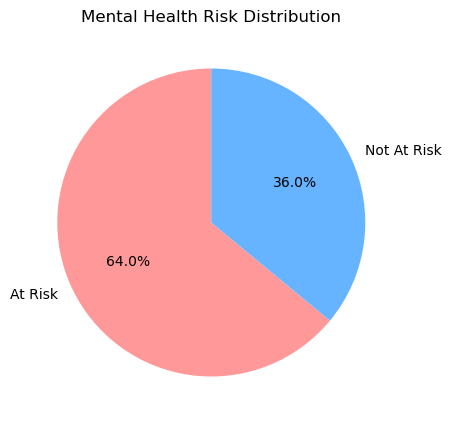

In [10]:
# Create the target column
clean_df['at_risk'] = ((clean_df['depression'] == 1) |
                       (clean_df['anxiety']    == 1) |
                       (clean_df['panic_attack']== 1)).astype(int)

print('Target distribution (1=At Risk, 0=Not At Risk):')
print(clean_df['at_risk'].value_counts())
print()

# Pie chart of risk distribution
counts = clean_df['at_risk'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(counts, labels=['At Risk', 'Not At Risk'], autopct='%1.1f%%',
        colors=['#ff9999', '#66b3ff'], startangle=90)
plt.title('Mental Health Risk Distribution')
plt.show()

## Step 7: Feature Selection
We pick the input columns (features) our model will learn from.

In [11]:
# Features the model will use to predict
FEATURES = ['gender', 'age', 'course', 'year', 'cgpa', 'married', 'treatment']

X = clean_df[FEATURES]   # Input features
y = clean_df['at_risk']  # Target label

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
X.head()

Features shape : (100, 7)
Target shape   : (100,)


,gender,age,course,year,cgpa,married,treatment
0,0,18.0,17,1,3,0,0
1,1,21.0,25,2,3,0,0
2,1,19.0,4,1,3,0,0
3,0,22.0,33,3,3,1,0
4,1,23.0,37,4,3,0,0


## Step 8: Split Data into Train & Test Sets

In [12]:
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 80
Testing  samples : 20


## Step 9: Train the ML Model (Random Forest)

In [13]:
# Create and train the model
model = RandomForestClassifier(
    n_estimators=100,  # 100 decision trees
    max_depth=4,       
    random_state=42
)

model.fit(X_train, y_train)
print('✅ Model trained successfully!')

✅ Model trained successfully!


## Step 10: Evaluate the Model

In [14]:
# Predict on test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100:.1f}%')
print()
print('Detailed Report:')
print(classification_report(y_test, y_pred, target_names=['Not At Risk', 'At Risk']))

Model Accuracy: 65.0%

Detailed Report:
              precision    recall  f1-score   support

 Not At Risk       1.00      0.12      0.22         8
     At Risk       0.63      1.00      0.77        12

    accuracy                           0.65        20
   macro avg       0.82      0.56      0.50        20
weighted avg       0.78      0.65      0.55        20



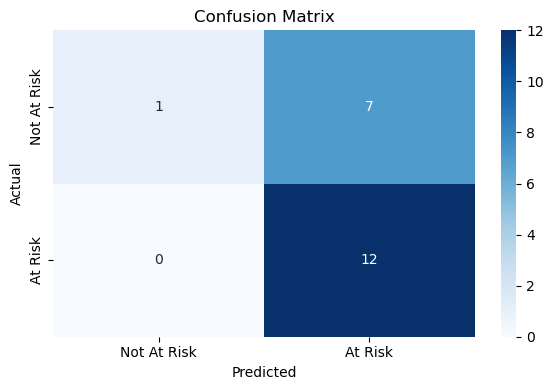

In [15]:
# Confusion Matrix — shows correct vs wrong predictions visually
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not At Risk', 'At Risk'],
            yticklabels=['Not At Risk', 'At Risk'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

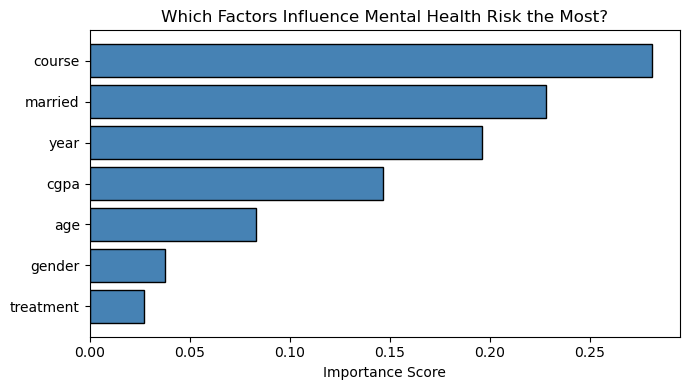

In [16]:
# Feature Importance — which lifestyle factor matters most?
importance_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue', edgecolor='black')
plt.title('Which Factors Influence Mental Health Risk the Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 11: Predict for a New Student
Enter details of a new student and predict their mental health risk.

In [17]:
def predict_student(gender, age, year, cgpa_encoded, married, treatment, course_encoded):
    """
    Predicts mental health risk for a new student.
    gender     : 1 = Male, 0 = Female
    age        : student age (e.g. 20)
    year       : year of study (1, 2, 3, or 4)
    cgpa_encoded : 0=low, 1=medium, 2=high (based on LabelEncoder order)
    married    : 1 = Yes, 0 = No
    treatment  : 1 = seeking treatment, 0 = not seeking
    course_encoded : encoded course number
    """
    input_data = pd.DataFrame([{
        'gender':   gender,
        'age':      age,
        'course':   course_encoded,
        'year':     year,
        'cgpa':     cgpa_encoded,
        'married':  married,
        'treatment': treatment
    }])
    
    prediction  = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0]
    
    print('─' * 40)
    print('Mental Health Risk Prediction')
    print('─' * 40)
    
    if prediction == 1:
        print('Result : AT RISK')
    else:
        print('Result : NOT AT RISK')
    
    print(f'Confidence — At Risk: {probability[1]*100:.1f}%  |  Not At Risk: {probability[0]*100:.1f}%')
    print('─' * 40)
    print('⚠️ This is a learning project, NOT a medical diagnosis.')


#sample
predict_student(
    gender=0,          # 0 = Female
    age=21,
    year=2,            # 2nd year
    cgpa_encoded=1,    # medium CGPA
    married=0,         # not married
    treatment=0,       # not seeking treatment
    course_encoded=2   # encoded course
)

────────────────────────────────────────
Mental Health Risk Prediction
────────────────────────────────────────
Result : AT RISK
Confidence — At Risk: 51.8%  |  Not At Risk: 48.2%
────────────────────────────────────────
⚠️ This is a learning project, NOT a medical diagnosis.
